# MWE: how well does AMI-like imaging recover known scenes?

An image reconstruction is only as trustworthy as its performance on simulated data with known answers. This notebook does that test for three truth scenes (a dusty spiral, an inclined lopsided ring, and an extended core with a compact, offset clump), each next to an analytic star, on simulated AMI-like DISCO data at three noise levels spanning a factor of ten. Every scene is reconstructed with maximum entropy, the best of the three regularisers in the L-curve MWE, with its weight chosen automatically by the discrepancy principle.

You should come away with a feel for what signal-to-noise AMI imaging needs, and a template for testing a reconstruction set-up on your own coverage before trusting it on real data.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from drpangloss.amigo import simulated_disco_record
from drpangloss.fitting import Problem
from drpangloss.imaging import MaxEntropy, image_priors, l_curve
from drpangloss.models import GaussianDisk, Image, PointSource, System
from drpangloss.oidata import OIData
from drpangloss.plotting import plot_model
from drpangloss.scenes import gaussian_blob, ring, spiral

npix, scale = 32, 10.0
scenes = {
    "spiral": spiral(
        npix, scale, step_mas=70.0, width_mas=12.0, turns=1.5, fade_mas=150.0
    ),
    "ring": ring(
        npix,
        scale,
        80.0,
        12.0,
        inc_deg=50.0,
        pa_deg=30.0,
        asymmetry=0.5,
        asymmetry_pa_deg=90.0,
    ),
    "core + clump": 0.7 * gaussian_blob(npix, scale, 30.0)
    + 0.3 * gaussian_blob(npix, scale, 8.0, dra=-60.0, ddec=50.0),
}
sigmas = [1e-4, 3e-4, 1e-3]  # ν Hor's DISCO errors are ~5e-5 to 2e-4
print(
    f"{len(scenes)} scenes x {len(sigmas)} noise levels; the extended emission has 10% of the star's flux"
)

3 scenes x 3 noise levels; the extended emission has 10% of the star's flux


## Reconstructing every case

For each scene and noise level, the data are simulated with a fixed seed, and a maximum-entropy L-curve over nine weights is fitted from a blurred Gaussian start. The weight is the one at which χ² per point reaches two standard deviations above one; the flux of the extended emission is held at its true value, so the test is of the image's shape. The whole loop takes one to two minutes.

In [2]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


start = System(
    star=PointSource(),
    env=Image.from_model(GaussianDisk(60.0), npix, scale, flux=0.1),
)
recovered = {}
for (name, truth_image), sigma in tqdm(
    [(s, sig) for s in scenes.items() for sig in sigmas]
):
    template = OIData(
        simulated_disco_record(
            wavelength_m=4.8e-6, rotation_deg=-6.9, sigma=sigma
        )
    )
    truth = System(
        star=PointSource(),
        env=Image.from_brightness(truth_image, scale, flux=0.1),
    )
    data = template.with_model(truth, key=jax.random.PRNGKey(0))
    curve = l_curve(
        lambda w: Problem(
            start, data, image_priors(start), [MaxEntropy(w, path="env")]
        ),
        jnp.logspace(0, 4, 9),
    )
    weight = (
        curve.discrepancy(1.0 + 2.0 * jnp.sqrt(2.0 / data.vis.size))
        or curve.corner()
    )
    best = int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(weight))))
    image = curve.results[best].model.env
    recovered[name, sigma] = (image, ncc(image.brightness, truth_image))
print("normalised cross-correlation with the truth:")
for name in scenes:
    print(
        f"  {name:>13}: "
        + "  ".join(f"σ={s:.0e} {recovered[name, s][1]:.3f}" for s in sigmas)
    )

  0%|          | 0/9 [00:00<?, ?it/s]

W0930 23:29:53.115460 9957882 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


normalised cross-correlation with the truth:
         spiral: σ=1e-04 0.869  σ=3e-04 0.801  σ=1e-03 0.719
           ring: σ=1e-04 0.993  σ=3e-04 0.985  σ=1e-03 0.957
   core + clump: σ=1e-04 0.940  σ=3e-04 0.882  σ=1e-03 0.812


## The reconstructions

Each row is one scene: the truth, then its reconstructions from the least to the most noisy data. The ring survives even the noisiest case, only a little blurred. The spiral keeps its winding only at the lowest noise; at higher noise its arms merge into a lopsided blob. The clump is always found in the right place, but a spurious bridge grows between it and the core. In each case the regulariser fills in structure that the noisier data no longer constrain.

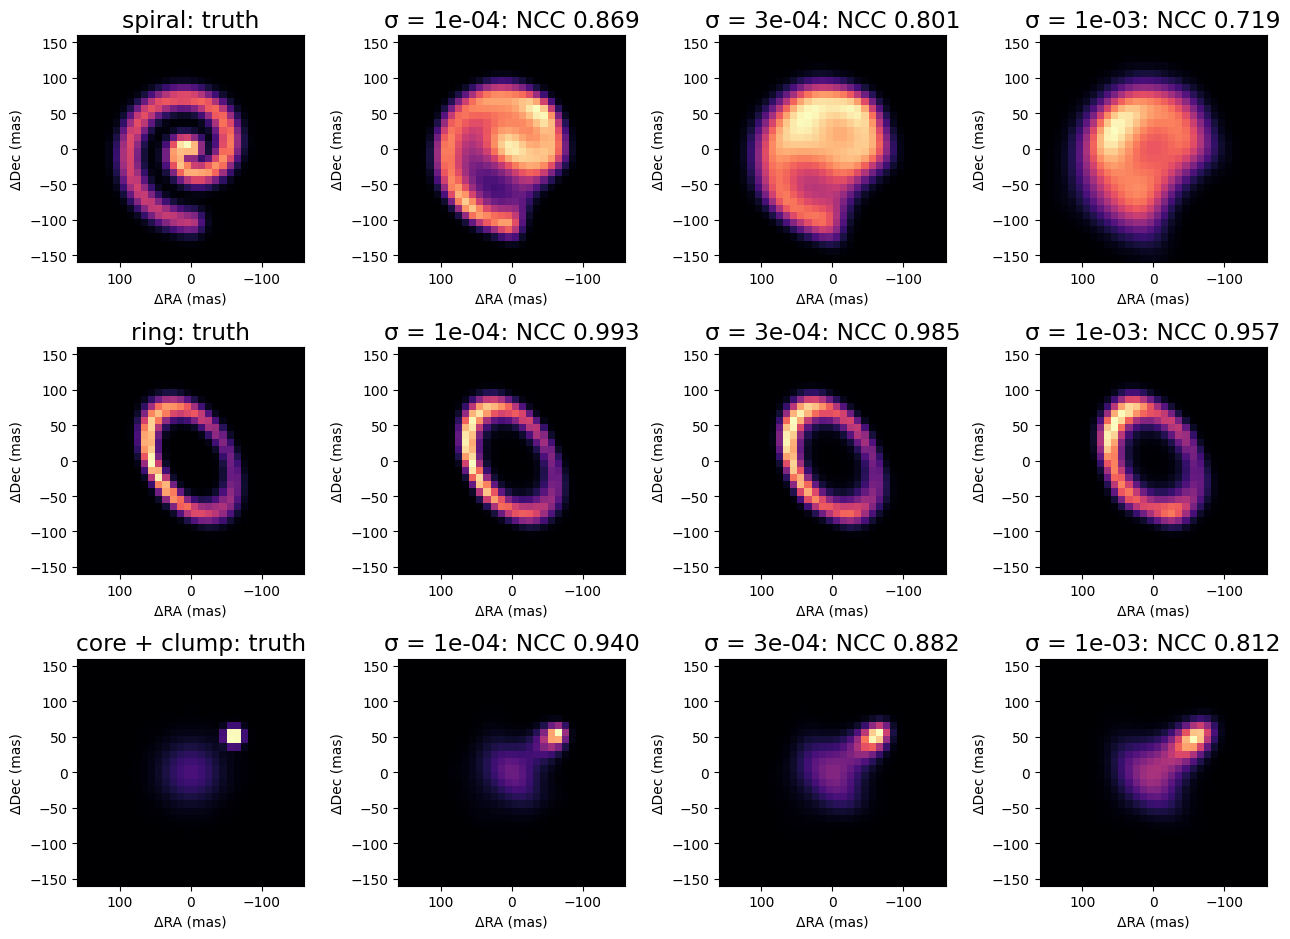

In [3]:
fig, axes = plt.subplots(len(scenes), len(sigmas) + 1, figsize=(13, 9.5))
for row, (name, truth_image) in zip(axes, scenes.items()):
    truth = Image.from_brightness(truth_image, scale)
    plot_model(
        truth,
        fov_mas=npix * scale,
        npix=npix,
        ax=row[0],
        title=f"{name}: truth",
    )
    for ax, sigma in zip(row[1:], sigmas):
        image, score = recovered[name, sigma]
        plot_model(
            image,
            fov_mas=npix * scale,
            npix=npix,
            ax=ax,
            title=f"σ = {sigma:.0e}: NCC {score:.3f}",
        )
plt.tight_layout()
plt.show()

## Recovery against signal-to-noise

The same numbers as a plot: the cross-correlation with the truth against the data error. Simple, high-contrast structure such as the ring degrades slowly; fine structure (the spiral's windings, the gap between clump and core) needs the lowest errors, comparable to those of the ν Hor data.

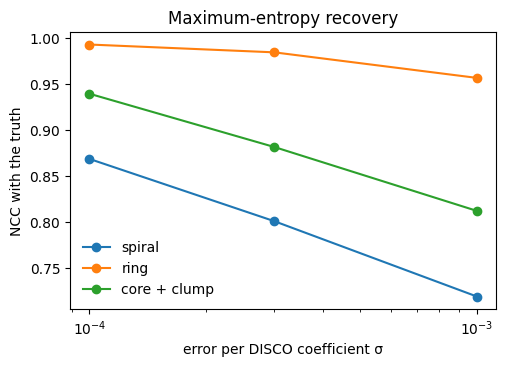

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 3.6))
for name in scenes:
    ax.semilogx(
        sigmas, [recovered[name, s][1] for s in sigmas], "-o", label=name
    )
ax.set(
    xlabel="error per DISCO coefficient σ",
    ylabel="NCC with the truth",
    title="Maximum-entropy recovery",
)
ax.legend(frameon=False)
plt.show()

## Summary

On simulated AMI-like data with errors like those of the ν Hor observations, maximum entropy with an automatically chosen weight recovers all three scenes well at the lowest noise, and recovery degrades gracefully as the errors grow tenfold, with fine structure lost first. To test your own set-up, replace the record with one matching your observation (rotation, wavelength, errors), the scenes with plausible truths for your target, and check that the reconstructions you would believe are the ones that match.